# IKEA Product Dimension Preprocessing Pipeline

## Cycle 1: Initial Data Acquisition and Dimension Extraction

### Data Download from Kagglehub

In [ ]:
import kagglehub

path = kagglehub.dataset_download("thedevastator/ikea-product")

print("Path to dataset files:", path)

100%|██████████| 155k/155k [00:00<00:00, 50.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/thedevastator/ikea-product/versions/2


### Initial Data Loading and Overview

In [ ]:
import pandas as pd
import os

files = os.listdir(path)
print("Files in directory:", files)

csv_file = [f for f in files if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)

df = pd.read_csv(full_path)

print("\n--- Dataset Info ---")
df.info()

print("\n--- First 3 Rows ---")
display(df.head(3))

Files in directory: ['ikea.csv']

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3694 entries, 0 to 3693
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         3694 non-null   int64  
 1   item_id            3694 non-null   int64  
 2   name               3694 non-null   object 
 3   category           3694 non-null   object 
 4   price              3694 non-null   float64
 5   old_price          3694 non-null   object 
 6   sellable_online    3694 non-null   bool   
 7   link               3694 non-null   object 
 8   other_colors       3694 non-null   object 
 9   short_description  3694 non-null   object 
 10  designer           3694 non-null   object 
 11  depth              2231 non-null   float64
 12  height             2706 non-null   float64
 13  width              3105 non-null   float64
dtypes: bool(1), float64(4), int64(2), object(7)
memory usage: 378.9+ 

,Unnamed: 0,item_id,name,category,price,old_price,sellable_online,link,other_colors,short_description,designer,depth,height,width
0,0,90420332,FREKVENS,Bar furniture,265.0,No old price,True,https://www.ikea.com/sa/en/p/frekvens-bar-tabl...,No,"Bar table, in/outdoor, 51x51 cm",Nicholai Wiig Hansen,NaN,99.0,51.0
1,1,368814,NORDVIKEN,Bar furniture,995.0,No old price,False,https://www.ikea.com/sa/en/p/nordviken-bar-tab...,No,"Bar table, 140x80 cm",Francis Cayouette,NaN,105.0,80.0
2,2,9333523,NORDVIKEN / NORDVIKEN,Bar furniture,2095.0,No old price,False,https://www.ikea.com/sa/en/p/nordviken-nordvik...,No,Bar table and 4 bar stools,Francis Cayouette,NaN,NaN,NaN


### Initial Missing Dimension Analysis

In [ ]:
columns_to_keep = ['item_id', 'name', 'category', 'short_description', 'depth', 'height', 'width']
df_clean = df[columns_to_keep].copy()

perfect_rows = df_clean.dropna(subset=['depth', 'height', 'width'])
print(f"Items with all 3 dimensions: {len(perfect_rows)} out of {len(df_clean)}")

missing_dims = df_clean[df_clean[['depth', 'height', 'width']].isnull().any(axis=1)]

print("\n--- Categories of items missing dimensions ---")
print(missing_dims['category'].value_counts())

Items with all 3 dimensions: 1899 out of 3694

--- Categories of items missing dimensions ---
category
Tables & desks                          509
Chairs                                  268
Sofas & armchairs                       205
Bookcases & shelving units              173
Outdoor furniture                       135
Beds                                    130
TV & media furniture                     95
Cabinets & cupboards                     93
Children's furniture                     46
Wardrobes                                37
Nursery furniture                        35
Bar furniture                            23
Trolleys                                 19
Café furniture                           13
Room dividers                             7
Chests of drawers & drawer units          4
Sideboards, buffets & console tables      3
Name: count, dtype: int64


### Detailed Missing Dimension Analysis

In [ ]:
print("--- Total Missing Values by Dimension ---")
print(missing_dims[['depth', 'height', 'width']].isnull().sum())

print("\n--- Example: Tables & Desks missing dimensions ---")
example_tables = missing_dims[missing_dims['category'] == 'Tables & desks'].head(5)
display(example_tables)

print("\n--- Example: Chairs missing dimensions ---")
example_chairs = missing_dims[missing_dims['category'] == 'Chairs'].head(5)
display(example_chairs)

--- Total Missing Values by Dimension ---
depth     1463
height     988
width      589
dtype: int64

--- Example: Tables & Desks missing dimensions ---


,item_id,name,category,short_description,depth,height,width
2628,19011777,MELLTORP,Tables & desks,"Table, 125x75 cm",NaN,74.0,75.0
2629,70466496,LJUV,Tables & desks,"Coffee table, 60x52 cm",NaN,28.0,52.0
2631,49011766,MELLTORP / ADDE,Tables & desks,"Table and 2 chairs, 75 cm",NaN,72.0,75.0
2632,59133593,LINNMON / ADILS,Tables & desks,"Corner table, 120x120 cm",NaN,74.0,120.0
2634,50411990,GLADOM,Tables & desks,"Tray table, 45x53 cm",NaN,53.0,NaN



--- Example: Chairs missing dimensions ---


,item_id,name,category,short_description,depth,height,width
1121,49011766,MELLTORP / ADDE,Chairs,"Table and 2 chairs, 75 cm",NaN,72.0,75.0
1122,10209202,MALINDA,Chairs,"Chair cushion, 40/35x38x7 cm",38.0,NaN,NaN
1125,79331865,LOBERGET / BLYSKÄR,Chairs,Swivel chair,67.0,NaN,67.0
1127,20339420,RENBERGET,Chairs,Swivel chair,65.0,NaN,59.0
1128,79046260,SNILLE,Chairs,Swivel chair,67.0,NaN,67.0


### Text-based Dimension Extraction Attempt

In [ ]:
import re
import numpy as np

def extract_dims_from_text(text):
    matches = re.findall(r'(\d+)', str(text))
    if len(matches) >= 2:
        return [float(m) for m in matches]
    return []

def fix_dimensions(row):
    dims = extract_dims_from_text(row['short_description'])

    if len(dims) >= 2:
        if pd.isna(row['depth']):
            row['depth'] = dims[0]
        if pd.isna(row['width']):
            row['width'] = dims[1] if len(dims) > 1 else dims[0]

    if pd.notna(row['width']) and pd.isna(row['depth']):
        row['depth'] = row['width']
    if pd.notna(row['depth']) and pd.isna(row['width']):
        row['width'] = row['depth']

    return row

print("🛠️ Running Dimension Rescue Operation...")
df_fixed = df_clean.apply(fix_dimensions, axis=1)

print("\n--- Remaining Missing Values ---")
print(df_fixed[['depth', 'height', 'width']].isnull().sum())

final_perfect = df_fixed.dropna(subset=['depth', 'height', 'width'])
print(f"\nPerfect items for 3D Engine: {len(final_perfect)} (Up from 1899!)")

🛠️ Running Dimension Rescue Operation...

--- Remaining Missing Values ---
depth     365
height    988
width     365
dtype: int64

Perfect items for 3D Engine: 2639 (Up from 1899!)


### Finalize and Export Initial RAG Dataset

In [ ]:
from google.colab import files

df_final = df_fixed.dropna(subset=['depth', 'height', 'width']).copy()

df_final['depth_m'] = df_final['depth'] / 100.0
df_final['height_m'] = df_final['height'] / 100.0
df_final['width_m'] = df_final['width'] / 100.0

def create_rag_string(row):
    return (f"Product: {row['name']} ({row['category']}). "
            f"Description: {row['short_description']}. "
            f"Physical Dimensions: Width {row['width_m']}m, Depth {row['depth_m']}m, Height {row['height_m']}m.")

df_final['rag_content'] = df_final.apply(create_rag_string, axis=1)

final_columns = ['item_id', 'name', 'category', 'rag_content', 'width_m', 'depth_m', 'height_m']
df_rag = df_final[final_columns]

output_path = "/content/ikea_dimensions_rag.json"
df_rag.to_json(output_path, orient='records', indent=4)

print(f"✅ Final dataset finalized with {len(df_rag)} items!")
print(f"📁 Saved to: {output_path}")

print("⬇️ Downloading to your local computer...")
files.download(output_path)

✅ Final dataset finalized with 2639 items!
📁 Saved to: /content/ikea_dimensions_rag.json
⬇️ Downloading to your local computer...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Cycle 2: Refining Dimensions and Initial Filtering

### Correcting Assembled Dimensions and Filtering Components

In [ ]:
import json
import re
import pandas as pd

JSON_PATH = "/content/ikea_dimensions_rag.json"
with open(JSON_PATH, 'r') as f:
    data = json.load(f)

df = pd.DataFrame(data)
print(f"📦 Starting row count: {len(df)}")

df = df[~df['name'].str.contains(r"\s/\s", regex=True)]

def is_component(text):
    text = str(text).lower()
    try:
        desc = text.split("description:")[1].split("physical dimensions:")[0].strip()
    except Exception:
        desc = text

    component_terms = [
        "headboard", "slatted bed base", "door", "drawer front",
        "cover for", "armrest", "cushion cover", "legs", "castor",
        "drawer without front", "glass door", "shelf", "panel", "frame for"
    ]

    for term in component_terms:
        if desc.startswith(term):
            return True

    return False

df['is_component'] = df['rag_content'].apply(is_component)
df = df[df['is_component'] == False]

def fix_assembled_dimensions(row):
    match = re.search(r'(\d+)\s*x\s*(\d+)(?:\s*x\s*(\d+))?\s*cm', str(row['rag_content']).lower())
    if match:
        dims = match.groups()
        real_w = float(dims[0]) / 100.0
        real_d = float(dims[1]) / 100.0

        if real_d > row['depth_m'] or real_w > row['width_m']:
            row['width_m'] = real_w
            row['depth_m'] = real_d
            if dims[2]:
                 row['height_m'] = float(dims[2]) / 100.0
            elif row['category'] == 'Beds' and row['height_m'] < 0.3:
                 row['height_m'] = 1.0
    return row

df = df.apply(fix_assembled_dimensions, axis=1)

df = df.drop(columns=['is_component'])

output_path = "/content/ikea_dimensions_rag_fixed.json"
df.to_json(output_path, orient='records', indent=4)

print(f"\n✅ Pruning complete! Slashed database down to {len(df)} core items.")
print(f"💾 Overwrote and saved to: {output_path}")

📦 Starting row count: 2639

✅ Pruning complete! Slashed database down to 2198 core items.
💾 Overwrote and saved to: /content/ikea_dimensions_rag_fixed.json


## Cycle 3: Advanced Data Pruning and Quality Assurance

### Import Libraries for Cleaning

In [ ]:
import pandas as pd
import numpy as np
import json

### Load Fixed Data for Further Pruning

In [ ]:
file_path = "/content/ikea_dimensions_rag_fixed.json"
with open(file_path, 'r') as f:
    data = json.load(f)
df = pd.DataFrame(data)

### Display Loaded Data

In [ ]:
df

,item_id,name,category,rag_content,width_m,depth_m,height_m
0,90420332,FREKVENS,Bar furniture,Product: FREKVENS (Bar furniture). Description...,0.51,0.51,0.99
1,368814,NORDVIKEN,Bar furniture,Product: NORDVIKEN (Bar furniture). Descriptio...,1.40,0.80,1.05
2,80155205,STIG,Bar furniture,Product: STIG (Bar furniture). Description: ...,0.60,0.50,1.00
3,30180504,NORBERG,Bar furniture,Product: NORBERG (Bar furniture). Description:...,0.74,0.60,0.43
4,10122647,INGOLF,Bar furniture,Product: INGOLF (Bar furniture). Description: ...,0.40,0.45,0.91
...,...,...,...,...,...,...,...
2193,89025790,PAX,Wardrobes,Product: PAX (Wardrobes). Description: ...,1.50,0.66,2.36
2194,29324320,PLATSA,Wardrobes,Product: PLATSA (Wardrobes). Description: ...,1.40,0.42,2.41
2195,19315156,ELVARLI,Wardrobes,Product: ELVARLI (Wardrobes). Description: ...,2.05,0.55,2.16
2196,19385677,PAX,Wardrobes,Product: PAX (Wardrobes). Description: ...,1.50,0.58,2.36


### Initial Cleaning and Outlier Removal

In [ ]:
print("🔍 --- INITIAL EDA REPORT ---")
print(f"Total starting items: {len(df)}")
print("\nItem count by category:")
print(df['category'].value_counts())

min_items = 5
valid_categories = df['category'].value_counts()[df['category'].value_counts() >= min_items].index
df_clean = df[df['category'].isin(valid_categories)].copy()

df_clean = df_clean[(df_clean['width_m'] > 0.05) & (df_clean['depth_m'] > 0.05) & (df_clean['height_m'] > 0.05)]

def remove_outliers(group, columns=['width_m', 'depth_m', 'height_m']):
    for col in columns:
        Q1 = group[col].quantile(0.25)
        Q3 = group[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        group = group[(group[col] >= lower_bound) & (group[col] <= upper_bound)]
    return group

df_clean = df_clean.groupby('category', group_keys=False).apply(remove_outliers)

print("\n✨ --- CLEANED RAG REPORT ---")
print(f"Total items remaining: {len(df_clean)} (Removed {len(df) - len(df_clean)} noisy items)")
print("\nCleaned item count by category:")
print(df_clean['category'].value_counts())

clean_output_path = "/content/ikea_rag_pristine.json"
df_clean.to_json(clean_output_path, orient='records', indent=4)
print(f"\n✅ Saved clean dataset to: {clean_output_path}")

🔍 --- INITIAL EDA REPORT ---
Total starting items: 2198

Item count by category:
category
Bookcases & shelving units              372
Sofas & armchairs                       250
Tables & desks                          249
Chairs                                  224
Cabinets & cupboards                    186
Wardrobes                               182
Beds                                    140
Chests of drawers & drawer units        119
Outdoor furniture                       118
TV & media furniture                     98
Children's furniture                     86
Nursery furniture                        66
Bar furniture                            32
Trolleys                                 27
Sideboards, buffets & console tables     23
Café furniture                           18
Room dividers                             8
Name: count, dtype: int64

✨ --- CLEANED RAG REPORT ---
Total items remaining: 1813 (Removed 385 noisy items)

Cleaned item count by category:
category
Bookcases 

/tmp/ipykernel_9018/1776456267.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_clean = df_clean.groupby('category', group_keys=False).apply(remove_outliers)


### Visualizing Data Distributions and Identifying Outliers

📊 --- STATISTICAL SUMMARY BY CATEGORY ---


width_m             depth_m              \
                                         min   max  mean     min   max  mean   
category                                                                       
Bar furniture                           0.38  0.60  0.45    0.36  0.53  0.47   
Beds                                    0.40  2.98  1.49    0.45  2.73  1.50   
Bookcases & shelving units              0.13  3.07  1.21    0.13  0.70  0.40   
Cabinets & cupboards                    0.25  2.43  1.01    0.20  1.75  0.63   
Café furniture                          0.46  0.54  0.52    0.46  0.51  0.49   
Chairs                                  0.22  1.05  0.56    0.21  0.94  0.57   
Chests of drawers & drawer units        0.25  1.61  0.77    0.23  1.45  0.76   
Children's furniture                    0.20  1.05  0.63    0.21  0.91  0.46   
Nursery furniture                       0.20  0.99  0.65    0.21  0.91  0.43   
Outdoor furniture                       0.36  2.87  1.12    0.36  0.94  0.72   
Room dividers                           1.47  1.82  1.59    1.47  1.82  1.59   
Sideboards, buffets & console tables    0.60  1.80  1.26    0.35  1.47  0.65   
Sofas & armchairs                       0.60  3.87  2.03    0.40  2.57  1.16   
TV & media furniture                    0.38  3.36  1.69    0.38  0.44  0.41   
Tables & desks                          0.27  2.40  1.00    0.23  1.15  0.64   
Trolleys                                0.26  1.26  0.71    0.18  0.79  0.49   
Wardrobes                               0.44  3.00  1.66    0.40  0.66  0.58   

                                     height_m              
                                          min   max  mean  
category                                                   
Bar furniture                            0.84  1.14  1.00  
Beds                                     0.53  1.35  0.93  
Bookcases & shelving units               0.10  2.40  1.30  
Cabinets & cupboards                     0.10  3.01  1.12  
Café furniture                           0.71  0.87  0.79  
Chairs                                   0.36  1.14  0.80  
Chests of drawers & drawer units         0.08  1.45  0.78  
Children's furniture                     0.10  0.94  0.58  
Nursery furniture                        0.10  1.78  0.71  
Outdoor furniture                        0.47  1.10  0.78  
Room dividers                            1.47  1.82  1.59  
Sideboards, buffets & console tables     0.35  1.93  1.04  
Sofas & armchairs                        0.43  1.04  0.86  
TV & media furniture                     0.10  2.51  1.13  
Tables & desks                           0.18  1.05  0.67  
Trolleys                                 0.65  0.97  0.84  
Wardrobes                                1.49  2.81  2.24


🎨 --- GENERATING VISUAL DISTRIBUTIONS ---


/tmp/ipykernel_9018/1729341739.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='width_m', ax=axes[0], palette="viridis")
/tmp/ipykernel_9018/1729341739.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='depth_m', ax=axes[1], palette="magma")
/tmp/ipykernel_9018/1729341739.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='height_m', ax=axes[2], palette="crest")


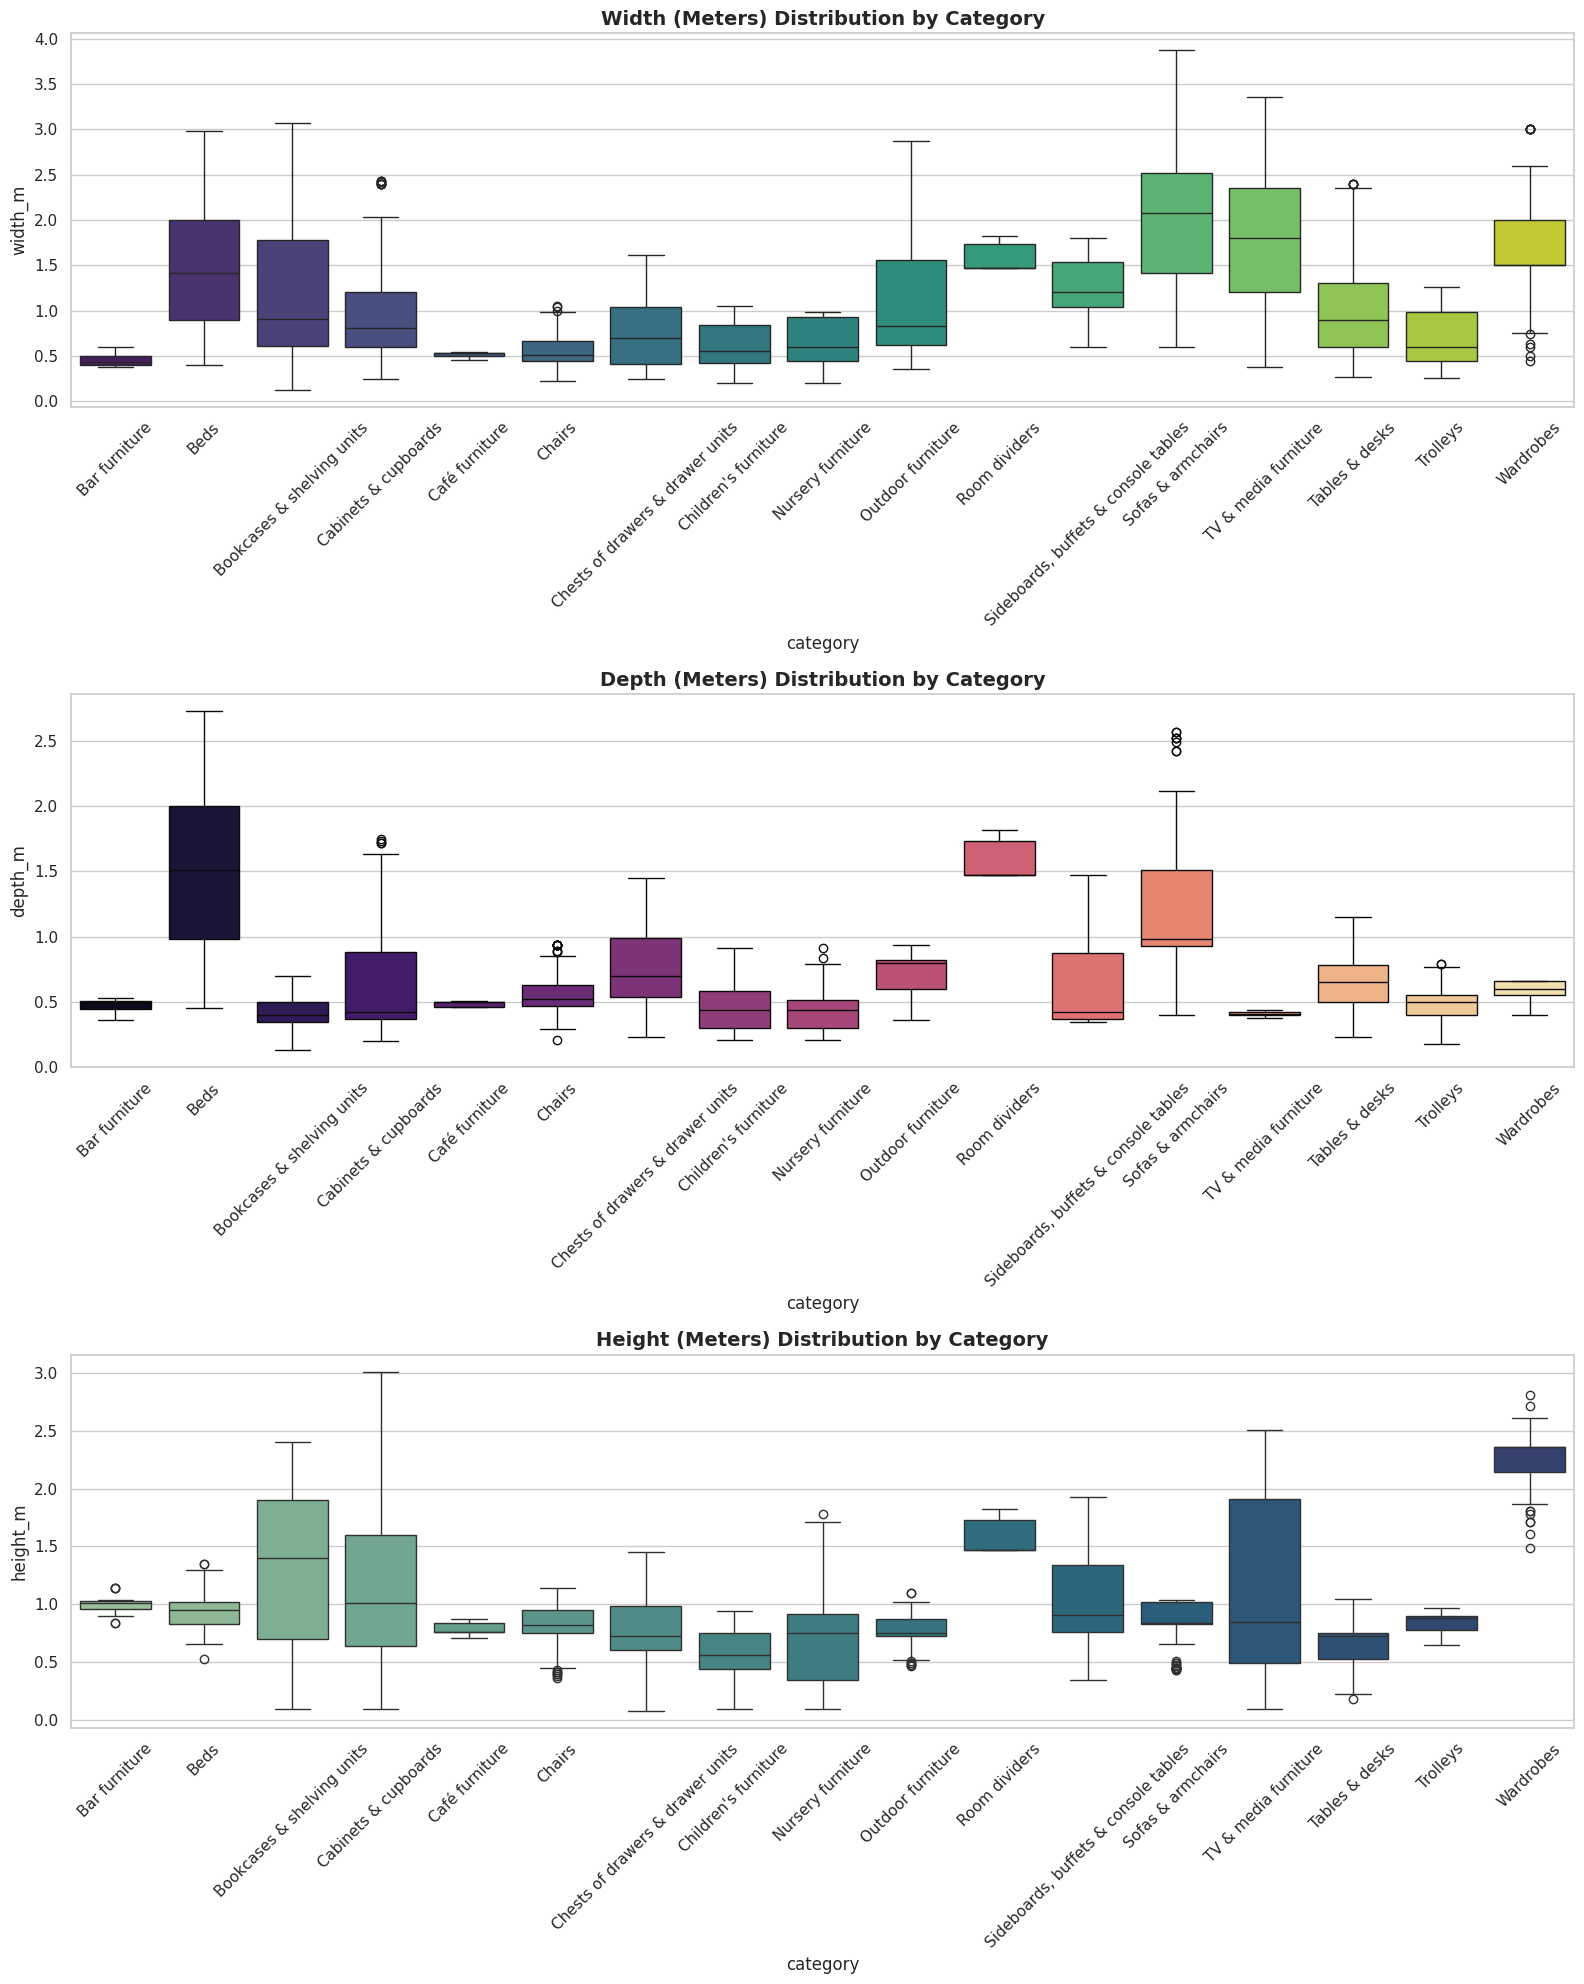


🦖 --- THE 'GIANTS' (Largest Volume Item Per Category) ---
[BAR FURNITURE]
   Name: STIG
   Dimensions: W: 0.6000000000000001m | D: 0.5m | H: 1.0m

[BEDS]
   Name: VALLENTUNA
   Dimensions: W: 2.73m | D: 2.73m | H: 0.84m

[BOOKCASES & SHELVING UNITS]
   Name: IVAR
   Dimensions: W: 2.59m | D: 0.5m | H: 2.26m

[CABINETS & CUPBOARDS]
   Name: LIXHULT
   Dimensions: W: 1.8m | D: 1.63m | H: 1.63m

[CAFÉ FURNITURE]
   Name: LEIFARNE
   Dimensions: W: 0.53m | D: 0.5m | H: 0.87m

[CHAIRS]
   Name: HAVSTEN
   Dimensions: W: 0.98m | D: 0.9400000000000001m | H: 0.9m

[CHESTS OF DRAWERS & DRAWER UNITS]
   Name: NORDLI
   Dimensions: W: 1.6m | D: 1.45m | H: 1.45m

[CHILDREN'S FURNITURE]
   Name: BUSUNGE
   Dimensions: W: 0.8m | D: 0.75m | H: 0.75m

[NURSERY FURNITURE]
   Name: STUVA
   Dimensions: W: 0.9m | D: 0.79m | H: 1.02m

[OUTDOOR FURNITURE]
   Name: HAVSTEN
   Dimensions: W: 2.6m | D: 0.9400000000000001m | H: 0.9m

[ROOM DIVIDERS]
   Name: KALLAX
   Dimensions: W: 1.82m | D: 1.82m | H: 1.82

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

file_path = "/content/ikea_rag_pristine.json"
df = pd.read_json(file_path)

print("📊 --- STATISTICAL SUMMARY BY CATEGORY ---")
stats = df.groupby('category')[['width_m', 'depth_m', 'height_m']].agg(['min', 'max', 'mean']).round(2)
display(stats)

print("\n🎨 --- GENERATING VISUAL DISTRIBUTIONS ---")
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 1, figsize=(16, 20))

sns.boxplot(data=df, x='category', y='width_m', ax=axes[0], palette="viridis")
axes[0].set_title('Width (Meters) Distribution by Category', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='category', y='depth_m', ax=axes[1], palette="magma")
axes[1].set_title('Depth (Meters) Distribution by Category', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='category', y='height_m', ax=axes[2], palette="crest")
axes[2].set_title('Height (Meters) Distribution by Category', fontsize=14, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n🦖 --- THE 'GIANTS' (Largest Volume Item Per Category) ---")
df['volume'] = df['width_m'] * df['depth_m'] * df['height_m']
idx_max_volume = df.groupby('category')['volume'].idxmax()
giants = df.loc[idx_max_volume]

for index, row in giants.iterrows():
    print(f"[{row['category'].upper()}]")
    print(f"   Name: {row['name']}")
    print(f"   Dimensions: W: {row['width_m']}m | D: {row['depth_m']}m | H: {row['height_m']}m\n")

### Further Pruning: Removing Modular Systems and Extreme Dimensions

In [ ]:
print("\n🧹 --- PURGING MODULAR SYSTEMS ---")
banned_words = ['combination', 'sectional', 'system', 'module', 'wall unit']

initial_count = len(df_clean)
pattern = '|'.join(banned_words)
df_clean = df_clean[~df_clean['name'].str.lower().str.contains(pattern, na=False)]

df_clean = df_clean[df_clean['width_m'] <= 2.6]
df_clean = df_clean[df_clean['depth_m'] <= 2.2]

print(f"Dropped {initial_count - len(df_clean)} massive modular combinations.")

clean_output_path = "/content/ikea_rag_pristine.json"
df_clean.to_json(clean_output_path, orient='records', indent=4)
print(f"✅ Saved ultra-clean dataset to: {clean_output_path}")


🧹 --- PURGING MODULAR SYSTEMS ---
Dropped 88 massive modular combinations.
✅ Saved ultra-clean dataset to: /content/ikea_rag_pristine.json


### Final Step: Remove Duplicate Items

In [ ]:
import pandas as pd
import json

PRISTINE_JSON_PATH = "/content/ikea_rag_pristine.json"
with open(PRISTINE_JSON_PATH, 'r') as f:
    data = json.load(f)
df = pd.DataFrame(data)

initial_count = len(df)

df_no_duplicates = df.drop_duplicates(subset=['item_id'])

final_count = len(df_no_duplicates)

df_no_duplicates.to_json(PRISTINE_JSON_PATH, orient='records', indent=4)

print(f"Removed {initial_count - final_count} duplicate items based on 'item_id'.")
print(f"Final item count: {final_count}")
print(f"✅ Cleaned dataset saved to: {PRISTINE_JSON_PATH}")

Removed 239 duplicate items based on 'item_id'.
Final item count: 1486
✅ Cleaned dataset saved to: /content/ikea_rag_pristine.json
